<a href="https://colab.research.google.com/github/bz2562-cmd/streamflow-wq-lstm/blob/main/%5BSB%5D_ICPlots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1:1 Ratio 3M NaCl

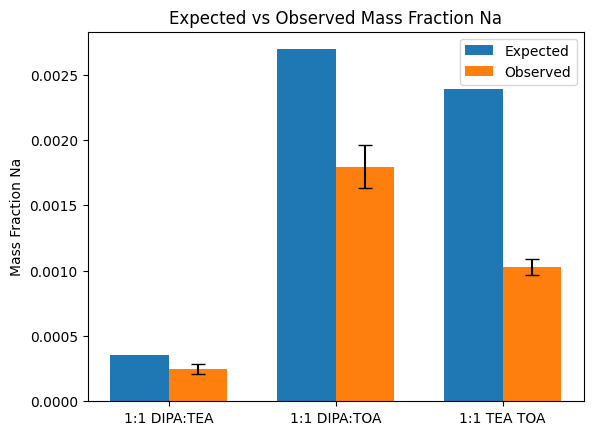

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
data = {
    "Pure DIPA": [7.00E-04, 6.23E-04],
    "Pure TEA": [6.56E-05, 2.90E-05],
    "Pure TOA": [4.63E-03, 4.82E-03],
    "1:1 DIPA:TEA": [2.10E-04, 2.87E-04],
    "1:1 DIPA:TOA": [1.63E-03, 1.96E-03],
    "1:1 TEA TOA": [1.09E-03, 9.70E-04],
}

# Means and ranges
means = {k: np.mean(v) for k, v in data.items()}
mins = {k: np.min(v) for k, v in data.items()}
maxs = {k: np.max(v) for k, v in data.items()}

# Expected values (average of pure components)
expected = {
    "1:1 DIPA:TEA": (means["Pure DIPA"] + means["Pure TEA"]) / 2,
    "1:1 DIPA:TOA": (means["Pure DIPA"] + means["Pure TOA"]) / 2,
    "1:1 TEA TOA": (means["Pure TEA"] + means["Pure TOA"]) / 2,
}

labels = list(expected.keys())
x = np.arange(len(labels))

observed_means = [means[l] for l in labels]
expected_means = [expected[l] for l in labels]

# Error bars (range)
observed_err = [
    [means[l] - mins[l] for l in labels],  # lower
    [maxs[l] - means[l] for l in labels],  # upper
]

# Plot
width = 0.35
plt.figure()

plt.bar(x - width/2, expected_means, width, label="Expected")
plt.bar(x + width/2, observed_means, width, yerr=observed_err, capsize=5, label="Observed")

plt.xticks(x, labels)
plt.ylabel("Mass Fraction Na")
plt.title("Expected vs Observed Mass Fraction Na")
plt.legend()

plt.show()


3:1 Ration 3M NaCl

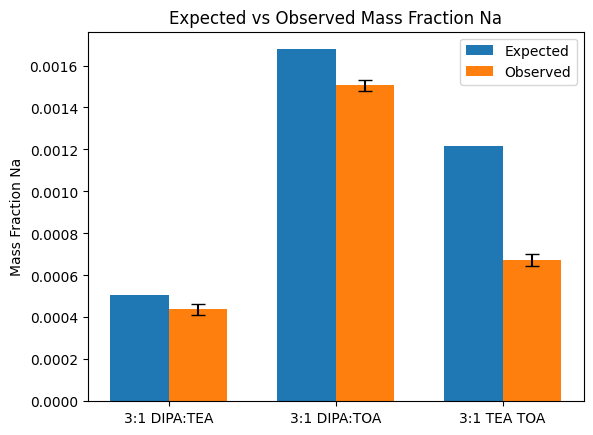

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
data = {
    "Pure DIPA": [7.00E-04, 6.23E-04],
    "Pure TEA": [6.56E-05, 2.90E-05],
    "Pure TOA": [4.63E-03, 4.82E-03],
    "3:1 DIPA:TEA": [4.63E-04, 4.12E-04],
    "3:1 DIPA:TOA": [1.48E-03, 1.53E-03],
    "3:1 TEA TOA": [6.43E-04, 7.02E-04],
}

# Means and ranges
means = {k: np.mean(v) for k, v in data.items()}
mins = {k: np.min(v) for k, v in data.items()}
maxs = {k: np.max(v) for k, v in data.items()}

# Expected values (average of pure components)
expected = {
    "3:1 DIPA:TEA": (3 * means["Pure DIPA"] + means["Pure TEA"]) / 4,
    "3:1 DIPA:TOA": (3 * means["Pure DIPA"] + means["Pure TOA"]) / 4,
    "3:1 TEA TOA": (3 * means["Pure TEA"] + means["Pure TOA"]) / 4,
}

labels = list(expected.keys())
x = np.arange(len(labels))

observed_means = [means[l] for l in labels]
expected_means = [expected[l] for l in labels]

# Error bars (range)
observed_err = [
    [means[l] - mins[l] for l in labels],  # lower
    [maxs[l] - means[l] for l in labels],  # upper
]

# Plot
width = 0.35
plt.figure()

plt.bar(x - width/2, expected_means, width, label="Expected")
plt.bar(x + width/2, observed_means, width, yerr=observed_err, capsize=5, label="Observed")

plt.xticks(x, labels)
plt.ylabel("Mass Fraction Na")
plt.title("Expected vs Observed Mass Fraction Na")
plt.legend()

plt.show()


Scatter Plot

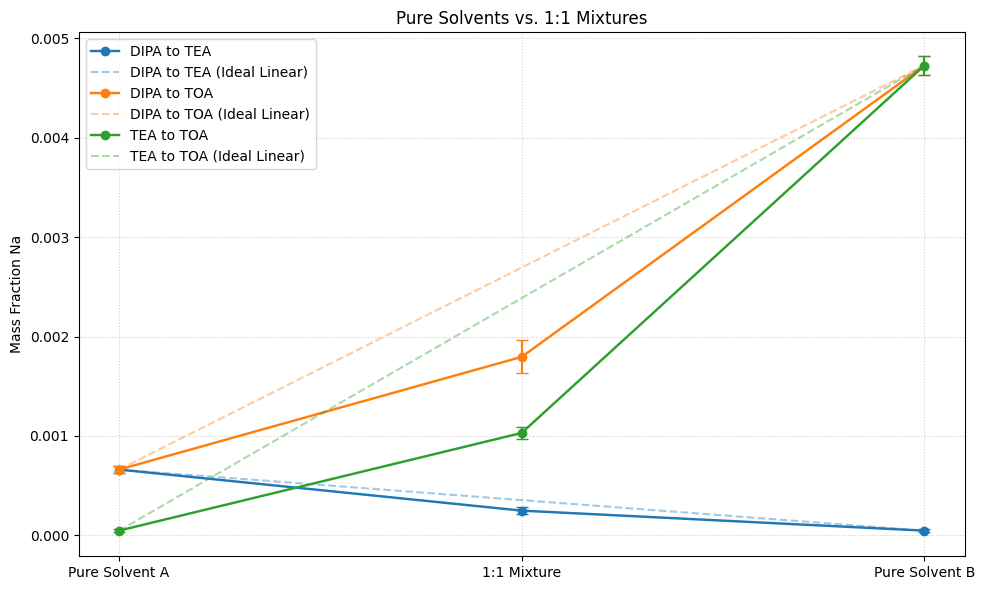

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
data = {
    "Pure DIPA": [7.00E-04, 6.23E-04],
    "Pure TEA": [6.56E-05, 2.90E-05],
    "Pure TOA": [4.63E-03, 4.82E-03],
    "1:1 DIPA:TEA": [2.10E-04, 2.87E-04],
    "1:1 DIPA:TOA": [1.63E-03, 1.96E-03],
    "1:1 TEA TOA": [1.09E-03, 9.70E-04],
}

# Means and ranges
means = {k: np.mean(v) for k, v in data.items()}
mins = {k: np.min(v) for k, v in data.items()}
maxs = {k: np.max(v) for k, v in data.items()}

# Define the solvent pairings for the X-axis mapping
# Format: (Pure Solvent A, 1:1 Mixture, Pure Solvent B, Label)
pairings = [
    ("Pure DIPA", "1:1 DIPA:TEA", "Pure TEA", "DIPA to TEA"),
    ("Pure DIPA", "1:1 DIPA:TOA", "Pure TOA", "DIPA to TOA"),
    ("Pure TEA", "1:1 TEA TOA", "Pure TOA", "TEA to TOA")
]

plt.figure(figsize=(10, 6))

# X-coordinates: 0 is Pure A, 0.5 is the 1:1 mixture, 1 is Pure B
x_coords = [0, 0.5, 1]

for pure_A, mix, pure_B, label in pairings:
    y_vals = [means[pure_A], means[mix], means[pure_B]]

    # Calculate lower and upper error bounds from the means
    y_err_lower = [means[pure_A] - mins[pure_A], means[mix] - mins[mix], means[pure_B] - mins[pure_B]]
    y_err_upper = [maxs[pure_A] - means[pure_A], maxs[mix] - means[mix], maxs[pure_B] - means[pure_B]]
    y_err = [y_err_lower, y_err_upper]

    # 1. Plot observed data with markers and solid lines
    line, = plt.plot(x_coords, y_vals, 'o-', label=label, markersize=6, linewidth=1.75)

    # 2. Add range error bars matching the line color
    plt.errorbar(x_coords, y_vals, yerr=y_err, fmt='none', ecolor=line.get_color(), capsize=4)

    # 3. Plot the "Ideal Linear" reference line (dashed line directly connecting endpoints)
    plt.plot([0, 1], [means[pure_A], means[pure_B]], '--', color=line.get_color(), alpha=0.4, label=f"{label} (Ideal Linear)")

# Formatting the plot
plt.xticks([0, 0.5, 1], ["Pure Solvent A", "1:1 Mixture", "Pure Solvent B"])
plt.ylabel("Mass Fraction Na")
plt.title("Pure Solvents vs. 1:1 Mixtures")

# Clean up the legend to avoid cluttering (or just use plt.legend())
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

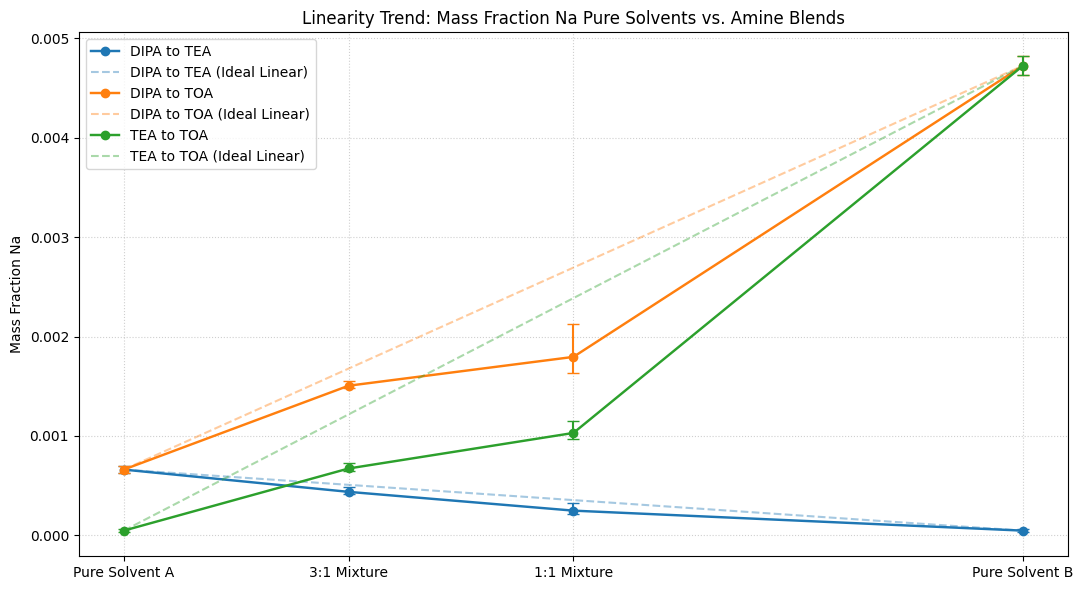

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
data = {
    "Pure DIPA": [7.00E-04, 6.23E-04],
    "Pure TEA": [6.56E-05, 2.90E-05],
    "Pure TOA": [4.63E-03, 4.82E-03],
    "3:1 DIPA:TEA": [4.63E-04, 4.12E-04],
    "1:1 DIPA:TEA": [2.10E-04, 2.87E-04],
    "3:1 DIPA:TOA": [1.48E-03, 1.53E-03],
    "1:1 DIPA:TOA": [1.63E-03, 1.96E-03],
    "3:1 TEA TOA": [6.43E-04, 7.02E-04],
    "1:1 TEA TOA": [1.09E-03, 9.70E-04],
}

# Means and ranges
means = {k: np.mean(v) for k, v in data.items()}
mins = {k: np.min(v) for k, v in data.items()}
maxs = {k: np.max(v) for k, v in data.items()}

# Define the solvent pairings for the X-axis mapping
# Format: (Pure Solvent A, 3:1 Mixture, 1:1 Mixture, Pure Solvent B, Label)
pairings = [
    ("Pure DIPA", "3:1 DIPA:TEA", "1:1 DIPA:TEA", "Pure TEA", "DIPA to TEA"),
    ("Pure DIPA", "3:1 DIPA:TOA", "1:1 DIPA:TOA", "Pure TOA", "DIPA to TOA"),
    ("Pure TEA", "3:1 TEA TOA", "1:1 TEA TOA", "Pure TOA", "TEA to TOA")
]

plt.figure(figsize=(11, 6))

# X-coordinates:
# 0 = Pure A, 0.25 = 3:1 mix (75% A), 0.5 = 1:1 mix (50% A), 1 = Pure B (0% A)
x_coords = [0, 0.25, 0.5, 1]

for pure_A, mix31, mix11, pure_B, label in pairings:
    y_vals = [means[pure_A], means[mix31], means[mix11], means[pure_B]]

    # Calculate lower and upper error bounds from the means
    y_err_lower = [means[pure_A] - mins[pure_A], means[mix31] - mins[mix31], means[mix11] - mins[mix11], means[pure_B] - mins[pure_B]]
    y_err_upper = [maxs[pure_A] - means[pure_A], maxs[mix31] - mins[mix31], maxs[mix11] - mins[mix11], maxs[pure_B] - means[pure_B]]
    y_err = [y_err_lower, y_err_upper]

    # 1. Plot observed data with markers and solid lines
    line, = plt.plot(x_coords, y_vals, 'o-', label=label, markersize=6, linewidth=1.75)

    # 2. Add range error bars matching the line color
    plt.errorbar(x_coords, y_vals, yerr=y_err, fmt='none', ecolor=line.get_color(), capsize=4)

    # 3. Plot the "Ideal Linear" reference line (dashed line directly connecting endpoints)
    plt.plot([0, 1], [means[pure_A], means[pure_B]], '--', color=line.get_color(), alpha=0.4, label=f"{label} (Ideal Linear)")

# Formatting the plot
plt.xticks([0, 0.25, 0.5, 1], ["Pure Solvent A", "3:1 Mixture", "1:1 Mixture", "Pure Solvent B"])
plt.ylabel("Mass Fraction Na")
plt.title("Linearity Trend: Mass Fraction Na Pure Solvents vs. Amine Blends")

plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.savefig('solvent_trend_updated.png')
plt.show()